In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
DATA_PATH = Path("../../Data/Analysis/master_orders.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print(df.columns.tolist())

Shape: (99441, 34)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_month', 'customer_unique_id', 'customer_city', 'customer_state', 'item_count', 'unique_products', 'unique_sellers', 'product_sales', 'freight_value', 'sales_value_incl_freight', 'payment_record_count', 'total_payment_value', 'unique_payment_types', 'max_installments', 'review_count', 'unique_review_ids', 'average_review_score', 'min_review_score', 'max_review_score', 'is_delivered', 'delivery_days', 'delivery_vs_estimate_days', 'is_late', 'has_review', 'has_payment', 'has_items']


### Loading and preparing the dates

In [3]:
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"],
    errors="coerce"
)

df["order_purchase_date"] = df["order_purchase_timestamp"].dt.date
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M")

print(df["order_purchase_timestamp"].min())
print(df["order_purchase_timestamp"].max())

2016-09-04 21:15:19
2018-10-17 17:30:18


### Keep delivered orders

In [4]:
delivered = df[
    df["is_delivered"] == True
].copy()

print("Delivered rows:", len(delivered))

Delivered rows: 96478


### Build the monthly dataset

In [5]:
monthly_sales = (
    delivered
    .groupby("order_month")
    .agg(
        delivered_sales=("sales_value_incl_freight", "sum"),
        delivered_orders=("order_id", "nunique"),
        product_sales=("product_sales", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

monthly_sales["order_month"] = monthly_sales["order_month"].dt.to_timestamp()

monthly_sales["aov"] = (
    monthly_sales["delivered_sales"]
    / monthly_sales["delivered_orders"]
)

monthly_sales

,order_month,delivered_sales,delivered_orders,product_sales,freight_value,aov
0,2016-09-01,143.46,1,134.97,8.49,143.460000
1,2016-10-01,46490.66,265,40325.11,6165.55,175.436453
2,2016-12-01,19.62,1,10.90,8.72,19.620000
3,2017-01-01,127482.37,750,111798.36,15684.01,169.976493
4,2017-02-01,271239.32,1653,234223.40,37015.92,164.089123
5,2017-03-01,414330.95,2546,359198.85,55132.10,162.738001
6,2017-04-01,390812.40,2303,340669.68,50142.72,169.697091
7,2017-05-01,566851.40,3546,489338.25,77513.15,159.856571
8,2017-06-01,490050.37,3135,421923.37,68127.00,156.315907
9,2017-07-01,566299.08,3872,481604.52,84694.56,146.254928


### Validating against our existing analysis

In [6]:
print(
    "Total delivered sales:",
    monthly_sales["delivered_sales"].sum()
)

print(
    "Total delivered orders:",
    monthly_sales["delivered_orders"].sum()
)

Total delivered sales: 15419773.749999998
Total delivered orders: 96478


### Visualize historical sales

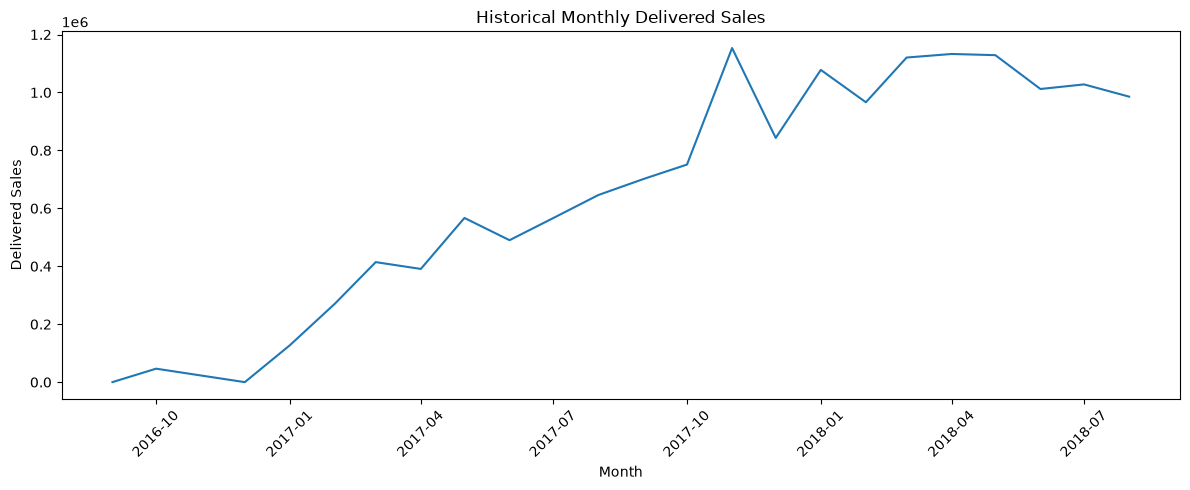

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["order_month"],
    monthly_sales["delivered_sales"]
)

plt.title("Historical Monthly Delivered Sales")
plt.xlabel("Month")
plt.ylabel("Delivered Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Creating a proper time-based validation split

In [8]:
train = monthly_sales.iloc[:-4].copy()
test = monthly_sales.iloc[-4:].copy()

print("Train period:", train["order_month"].min(), "to", train["order_month"].max())
print("Test period:", test["order_month"].min(), "to", test["order_month"].max())

Train period: 2016-09-01 00:00:00 to 2018-04-01 00:00:00
Test period: 2018-05-01 00:00:00 to 2018-08-01 00:00:00


### First model: baseline

Before using a sophisticated model, we'll create a naive baseline.

In [9]:
baseline_forecast = test["delivered_sales"].shift(1)

baseline_forecast.iloc[0] = train["delivered_sales"].iloc[-1]

print(baseline_forecast)

19    1132878.93
20    1128774.52
21    1011978.29
22    1027807.28
Name: delivered_sales, dtype: float64


### Create the baseline forecast

In [10]:
# Naive baseline forecast
# Predict every future month using the last observed training value

baseline_forecast = np.repeat(
    train["delivered_sales"].iloc[-1],
    len(test)
)

baseline_results = test[["order_month", "delivered_sales"]].copy()
baseline_results["baseline_forecast"] = baseline_forecast

baseline_results

,order_month,delivered_sales,baseline_forecast
19,2018-05-01,1128774.52,1132878.93
20,2018-06-01,1011978.29,1132878.93
21,2018-07-01,1027807.28,1132878.93
22,2018-08-01,985491.64,1132878.93


### Evaluate the baseline

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline_mae = mean_absolute_error(
    test["delivered_sales"],
    baseline_results["baseline_forecast"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        test["delivered_sales"],
        baseline_results["baseline_forecast"]
    )
)

baseline_mape = (
    np.mean(
        np.abs(
            (test["delivered_sales"] - baseline_results["baseline_forecast"])
            / test["delivered_sales"]
        )
    ) * 100
)

print("Baseline MAE :", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline MAPE:", round(baseline_mape, 2), "%")

Baseline MAE : 94366.0
Baseline RMSE: 108854.12
Baseline MAPE: 9.37 %


### Build the first real forecasting model

### Create a continuous monthly index

In [17]:
# Make sure order_month is datetime
monthly_sales["order_month"] = pd.to_datetime(monthly_sales["order_month"])

# Set month as index and create a continuous monthly frequency
monthly_sales = (
    monthly_sales
    .set_index("order_month")
    .asfreq("MS")
)

monthly_sales

,delivered_sales,delivered_orders,product_sales,freight_value,aov
order_month,,,,,
2016-09-01,143.46,1.0,134.97,8.49,143.460000
2016-10-01,46490.66,265.0,40325.11,6165.55,175.436453
2016-11-01,NaN,NaN,NaN,NaN,NaN
2016-12-01,19.62,1.0,10.90,8.72,19.620000
2017-01-01,127482.37,750.0,111798.36,15684.01,169.976493
2017-02-01,271239.32,1653.0,234223.40,37015.92,164.089123
2017-03-01,414330.95,2546.0,359198.85,55132.10,162.738001
2017-04-01,390812.40,2303.0,340669.68,50142.72,169.697091
2017-05-01,566851.40,3546.0,489338.25,77513.15,159.856571


### Fill the missing month's sales-related values

In [18]:
# Fill missing values created by the missing November 2016 month
monthly_sales["delivered_sales"] = monthly_sales["delivered_sales"].fillna(0)
monthly_sales["delivered_orders"] = monthly_sales["delivered_orders"].fillna(0)
monthly_sales["product_sales"] = monthly_sales["product_sales"].fillna(0)
monthly_sales["freight_value"] = monthly_sales["freight_value"].fillna(0)

# Recalculate AOV safely
monthly_sales["aov"] = np.where(
    monthly_sales["delivered_orders"] > 0,
    monthly_sales["delivered_sales"] / monthly_sales["delivered_orders"],
    np.nan
)

monthly_sales

,delivered_sales,delivered_orders,product_sales,freight_value,aov
order_month,,,,,
2016-09-01,143.46,1.0,134.97,8.49,143.460000
2016-10-01,46490.66,265.0,40325.11,6165.55,175.436453
2016-11-01,0.00,0.0,0.00,0.00,NaN
2016-12-01,19.62,1.0,10.90,8.72,19.620000
2017-01-01,127482.37,750.0,111798.36,15684.01,169.976493
2017-02-01,271239.32,1653.0,234223.40,37015.92,164.089123
2017-03-01,414330.95,2546.0,359198.85,55132.10,162.738001
2017-04-01,390812.40,2303.0,340669.68,50142.72,169.697091
2017-05-01,566851.40,3546.0,489338.25,77513.15,159.856571


### Recreate train and test

In [19]:
train = monthly_sales.iloc[:-4].copy()
test = monthly_sales.iloc[-4:].copy()

print(
    "Train period:",
    train.index.min(),
    "to",
    train.index.max()
)

print(
    "Test period:",
    test.index.min(),
    "to",
    test.index.max()
)

Train period: 2016-09-01 00:00:00 to 2018-04-01 00:00:00
Test period: 2018-05-01 00:00:00 to 2018-08-01 00:00:00


### Fit the Holt model

In [20]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

train_series = train["delivered_sales"]

holt_model = ExponentialSmoothing(
    train_series,
    trend="add",
    seasonal=None,
    initialization_method="estimated"
).fit()

holt_forecast = holt_model.forecast(len(test))

holt_results = test[["delivered_sales"]].copy()
holt_results["holt_forecast"] = holt_forecast.values

holt_results

,delivered_sales,holt_forecast
order_month,,
2018-05-01,1128774.52,1.268691e+06
2018-06-01,1011978.29,1.336204e+06
2018-07-01,1027807.28,1.403718e+06
2018-08-01,985491.64,1.471231e+06


### Evaluate the Holt model

In [21]:
holt_mae = mean_absolute_error(
    test["delivered_sales"],
    holt_results["holt_forecast"]
)

holt_rmse = np.sqrt(
    mean_squared_error(
        test["delivered_sales"],
        holt_results["holt_forecast"]
    )
)

holt_mape = (
    np.mean(
        np.abs(
            (test["delivered_sales"] - holt_results["holt_forecast"])
            / test["delivered_sales"]
        )
    ) * 100
)

print("Holt MAE :", round(holt_mae, 2))
print("Holt RMSE:", round(holt_rmse, 2))
print("Holt MAPE:", round(holt_mape, 2), "%")

Holt MAE : 331448.01
Holt RMSE: 354242.37
Holt MAPE: 32.57 %


In [22]:
model_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Holt Linear Trend"
    ],
    "MAE": [
        baseline_mae,
        holt_mae
    ],
    "RMSE": [
        baseline_rmse,
        holt_rmse
    ],
    "MAPE (%)": [
        baseline_mape,
        holt_mape
    ]
})

model_comparison

,Model,MAE,RMSE,MAPE (%)
0,Naive Baseline,94365.99750,108854.117769,9.372296
1,Holt Linear Trend,331448.01243,354242.371023,32.574326


### Test Simple Exponential Smoothing

In [26]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(
    train["delivered_sales"],
    initialization_method="estimated"
).fit()

ses_forecast = ses_model.forecast(len(test))

ses_results = test[["delivered_sales"]].copy()
ses_results["ses_forecast"] = ses_forecast.values

ses_results

,delivered_sales,ses_forecast
order_month,,
2018-05-01,1128774.52,1.122792e+06
2018-06-01,1011978.29,1.122792e+06
2018-07-01,1027807.28,1.122792e+06
2018-08-01,985491.64,1.122792e+06


In [27]:
ses_mae = mean_absolute_error(
    test["delivered_sales"],
    ses_results["ses_forecast"]
)

ses_rmse = np.sqrt(
    mean_squared_error(
        test["delivered_sales"],
        ses_results["ses_forecast"]
    )
)

ses_mape = (
    np.mean(
        np.abs(
            (test["delivered_sales"] - ses_results["ses_forecast"])
            / test["delivered_sales"]
        )
    ) * 100
)

print("SES MAE :", round(ses_mae, 2))
print("SES RMSE:", round(ses_rmse, 2))
print("SES MAPE:", round(ses_mape, 2), "%")

SES MAE : 87270.26
SES RMSE: 100235.8
SES MAPE: 8.66 %


### Create the final model comparison

In [28]:
model_comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Simple Exponential Smoothing",
        "Holt Linear Trend"
    ],
    "MAE": [
        baseline_mae,
        ses_mae,
        holt_mae
    ],
    "RMSE": [
        baseline_rmse,
        ses_rmse,
        holt_rmse
    ],
    "MAPE (%)": [
        baseline_mape,
        ses_mape,
        holt_mape
    ]
})

model_comparison.sort_values("MAPE (%)")

,Model,MAE,RMSE,MAPE (%)
1,Simple Exponential Smoothing,87270.258273,100235.798755,8.663460
0,Naive Baseline,94365.997500,108854.117769,9.372296
2,Holt Linear Trend,331448.012430,354242.371023,32.574326


### Create the final 6-month forecast

In [29]:
# Final model: Simple Exponential Smoothing
# Train on the complete historical monthly series

full_series = monthly_sales["delivered_sales"]

final_ses_model = SimpleExpSmoothing(
    full_series,
    initialization_method="estimated"
).fit()

forecast_months = 6

future_forecast = final_ses_model.forecast(forecast_months)

future_dates = pd.date_range(
    start=full_series.index.max() + pd.offsets.MonthBegin(1),
    periods=forecast_months,
    freq="MS"
)

future_forecast_df = pd.DataFrame({
    "order_month": future_dates,
    "forecast_sales": future_forecast.values
})

future_forecast_df

,order_month,forecast_sales
0,2018-09-01,995710.728741
1,2018-10-01,995710.728741
2,2018-11-01,995710.728741
3,2018-12-01,995710.728741
4,2019-01-01,995710.728741
5,2019-02-01,995710.728741


### Create the Power BI-ready forecast dataset

In [30]:
# Historical actual sales
historical_df = monthly_sales.reset_index()[[
    "order_month",
    "delivered_sales"
]].copy()

historical_df = historical_df.rename(
    columns={"delivered_sales": "actual_sales"}
)

historical_df["forecast_sales"] = np.nan
historical_df["is_forecast"] = False
historical_df["model"] = "Historical Actual"


# Future forecast
forecast_df = future_forecast_df.copy()

forecast_df["actual_sales"] = np.nan
forecast_df["is_forecast"] = True
forecast_df["model"] = "Simple Exponential Smoothing"

forecast_df = forecast_df[[
    "order_month",
    "actual_sales",
    "forecast_sales",
    "is_forecast",
    "model"
]]


# Combine historical + forecast
sales_forecast = pd.concat(
    [historical_df, forecast_df],
    ignore_index=True
)

sales_forecast

,order_month,actual_sales,forecast_sales,is_forecast,model
0,2016-09-01,143.46,NaN,False,Historical Actual
1,2016-10-01,46490.66,NaN,False,Historical Actual
2,2016-11-01,0.00,NaN,False,Historical Actual
3,2016-12-01,19.62,NaN,False,Historical Actual
4,2017-01-01,127482.37,NaN,False,Historical Actual
5,2017-02-01,271239.32,NaN,False,Historical Actual
6,2017-03-01,414330.95,NaN,False,Historical Actual
7,2017-04-01,390812.40,NaN,False,Historical Actual
8,2017-05-01,566851.40,NaN,False,Historical Actual
9,2017-06-01,490050.37,NaN,False,Historical Actual


Save it to your project

In [31]:
from pathlib import Path

OUTPUT_PATH = Path("../../Data/Analysis/sales_forecast.csv")

sales_forecast.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved to:", OUTPUT_PATH.resolve())

Saved to: E:\ShopSphere_Analysis\Data\Analysis\sales_forecast.csv


In [32]:
print(sales_forecast.tail(6))
print("\nShape:", sales_forecast.shape)

   order_month  actual_sales  forecast_sales  is_forecast  \
24  2018-09-01           NaN   995710.728741         True   
25  2018-10-01           NaN   995710.728741         True   
26  2018-11-01           NaN   995710.728741         True   
27  2018-12-01           NaN   995710.728741         True   
28  2019-01-01           NaN   995710.728741         True   
29  2019-02-01           NaN   995710.728741         True   

                           model  
24  Simple Exponential Smoothing  
25  Simple Exponential Smoothing  
26  Simple Exponential Smoothing  
27  Simple Exponential Smoothing  
28  Simple Exponential Smoothing  
29  Simple Exponential Smoothing  

Shape: (30, 5)


### Save model evaluation results

In [33]:
comparison_output = model_comparison.copy()

comparison_path = Path(
    "../outputs/forecast_model_comparison.csv"
)

comparison_output.to_csv(
    comparison_path,
    index=False
)

print("Saved to:", comparison_path.resolve())

Saved to: E:\ShopSphere_Analysis\09_Predictive_Analytics\outputs\forecast_model_comparison.csv


### Create the final forecast visualization

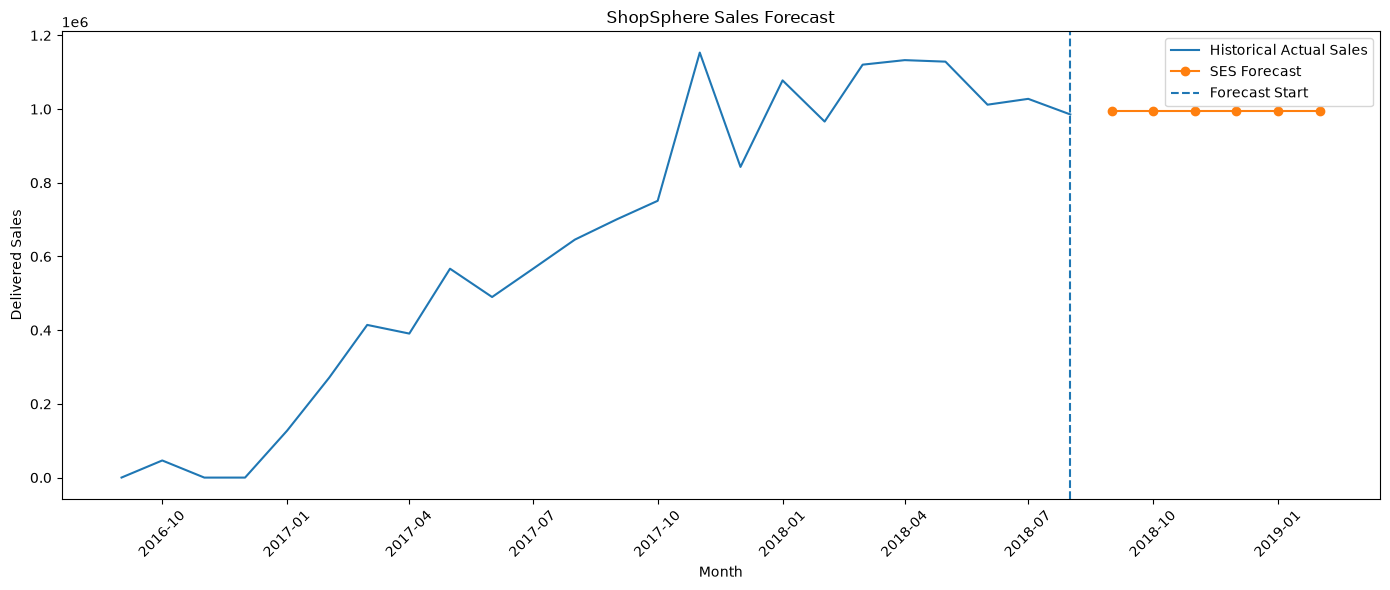

Chart saved to: E:\ShopSphere_Analysis\09_Predictive_Analytics\outputs\sales_forecast.png


In [35]:
plt.figure(figsize=(14, 6))

historical = sales_forecast[
    sales_forecast["is_forecast"] == False
]

forecast = sales_forecast[
    sales_forecast["is_forecast"] == True
]

plt.plot(
    historical["order_month"],
    historical["actual_sales"],
    label="Historical Actual Sales"
)

plt.plot(
    forecast["order_month"],
    forecast["forecast_sales"],
    marker="o",
    label="SES Forecast"
)

plt.axvline(
    full_series.index.max(),
    linestyle="--",
    label="Forecast Start"
)

plt.xlabel("Month")
plt.ylabel("Delivered Sales")
plt.title("ShopSphere Sales Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

forecast_chart_path = Path(
    "../outputs/sales_forecast.png"
)

plt.savefig(
    forecast_chart_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Chart saved to:", forecast_chart_path.resolve())